# DTSC-580 Data Manipulation

## Assignment:  NYC Payroll Assignment

### Name:

<img src="NYC_OpenData_Logo.png">

## Assignment Overview
In this assignment, you will use payroll data downloaded from NYC Open Data to answer specific questions.  These questions just scratch the surface of analysis possibilities, and if you have additional time, it would be great practice to come up with questions on your own and try to answer them with the data.

After you finish answering the questions using the provided data, you can then take the exam in Brightspace which will include questions from this data set plus more general questions about data aggregation, data grouping, and multi-level indexing.

Note that you will not be uploading your code to CodeGrade for checking and instead will complete this assignment and use the answers to complete a quiz.

## Data
As mentioned above, this data is from [NYC Open Data](https://data.cityofnewyork.us/City-Government/Citywide-Payroll-Data-Fiscal-Year-/k397-673e) and represents NYC employees’ salary and overtime pay data.  The following is from the data dictionary that has also been included in the download files for your reference:

```
Data is collected because of public interest in how the City’s budget is being spent on salary and overtime pay for all municipal employees. Data is input into the City's Personnel Management System (“PMS”) by the respective user Agencies. Each record represents the following statistics for every city employee: Agency, Last Name, First Name, Middle Initial, Agency Start Date, Work Location Borough, Job Title Description, Leave Status as of the close of the FY (June 30th), Base Salary, Pay Basis, Regular Hours Paid, Regular Gross Paid, Overtime Hours worked, Total Overtime Paid, and Total Other Compensation (i.e. lump sum and/or retro payments). This data can be used to analyze how the City's financial resources are allocated and how much of the City's budget is being devoted to overtime. The reader of this data should be aware that increments of salary increases received over the course of any one fiscal year will not be reflected. All that is captured, is the employee's final base and gross salary at the end of the fiscal year.

NOTE: As a part of FISA-OPA’s routine process for reviewing and releasing Citywide Payroll Data, data for some agencies (specifically NYC Police Department (NYPD) and the District Attorneys’ Offices (Manhattan, Kings, Queens, Richmond, Bronx, and Special Narcotics)) have been redacted since they are exempt from disclosure pursuant to the Freedom of Information Law, POL § 87(2)(f), on the ground that disclosure of the information could endanger the life and safety of the public servants listed thereon. They are further exempt from disclosure pursuant to POL § 87(2)(e)(iii), on the ground that any release of the information would identify confidential sources or disclose confidential information relating to a criminal investigation, and POL § 87(2)(e)(iv), on the ground that disclosure would reveal non-routine criminal investigative techniques or procedures.
```
**Important:**  The csv file is large and it may take several minutes to read the data into a DataFrame depending on your computer.  Because of the large file size, when you try to read the data, you may get a warning message about mixed data types.  To prevent this warning message, you should include a data type argument for the columns when using [pd.read_csv()](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) to ensure that Pandas will use the appropriate data type.  See [this article](https://www.roelpeters.be/solved-dtypewarning-columns-have-mixed-types-specify-dtype-option-on-import-or-set-low-memory-in-pandas/) for more information on this warning message.



In [2]:
# common imports
import pandas as pd
import numpy as np

In [4]:
# import data - use dtype argument due to large file size
nyc_full = pd.read_csv('NYC_Payroll_Data.csv', dtype={'Fiscal Year': 'int', 'Payroll Number': 'float', 'Agency Name': 'str',
                                                            'Last Name': 'str','First Name': 'str','Mid Init': 'str',
                                                            'Agency Start Date': 'str','Work Location Borough': 'str','Title Description': 'str',
                                                            'Leave Status as of June 30': 'str','Base Salary': 'float','Pay Basis': 'str',
                                                            'Regular Hours': 'float', 'Regular Gross Paid': 'float', 'OT Hours': 'float',
                                                            'Total OT Paid': 'float', 'Total Other Pay': 'float'})

In [6]:
# make copy of data so you do not need to import again if you make a mistake and need to "reset"
nyc = nyc_full.copy()

In [10]:
# check information about DataFrame
#nyc.info()
nyc.shape

(4496767, 17)

In [12]:
# check first five rows of data
nyc.head()

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
0,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,BEREZIN,MIKHAIL,NaN,08/10/2015,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0
1,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,GEAGER,VERONICA,M,09/12/2016,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0
2,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,RAMANI,SHRADDHA,NaN,02/22/2016,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0
3,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,ROTTA,JONATHAN,D,09/16/2013,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0
4,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,WILSON II,ROBERT,P,04/30/2018,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,per Annum,1820.0,84698.21,0.0,0.0,0.0


If you were to research the values in the DataFrame further, you will notice that there are some values in lowercase and most are listed in all uppercase.  Because of this, run the function below that will transform all characters to uppercase to be consistent with the majority of the data.  

In [14]:
# run this code block
def upper_case(df):
    '''
    Takes as input the `nyc` DataFrame. 
    Then capitlizes each character in columns with "object" data type.
    '''
    # iterating over each column in the DataFrame
    for col in df.columns:
        # checking datatype of each column
        if df[col].dtype == 'object':
            # applying upper function on column
            df[col] = df[col].str.upper()

upper_case(nyc)

**Q1:** How many rows are contained in the full dataset?

In [34]:
### ENTER CODE HERE ###
nyc.shape
nyc.columns
nyc.head()

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
0,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,BEREZIN,MIKHAIL,NaN,08/10/2015,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,PER ANNUM,1820.0,84698.21,0.0,0.0,0.0
1,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,GEAGER,VERONICA,M,09/12/2016,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,PER ANNUM,1820.0,84698.21,0.0,0.0,0.0
2,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,RAMANI,SHRADDHA,NaN,02/22/2016,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,PER ANNUM,1820.0,84698.21,0.0,0.0,0.0
3,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,ROTTA,JONATHAN,D,09/16/2013,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,PER ANNUM,1820.0,84698.21,0.0,0.0,0.0
4,2020,17.0,OFFICE OF EMERGENCY MANAGEMENT,WILSON II,ROBERT,P,04/30/2018,BROOKLYN,EMERGENCY PREPAREDNESS MANAGER,ACTIVE,86005.0,PER ANNUM,1820.0,84698.21,0.0,0.0,0.0


*Note:  Most of the following questions refer to the 2021 fiscal year data.  It might help if you create a new DataFrame for only 2021 data.*

In [44]:
### ENTER CODE HERE ###
#data[['b','d']]
nyc_2021 = nyc[nyc['Fiscal Year'] == 2021]

**Q2:** How many individuals are represented using only the 2021 fiscal year data?

In [42]:
### ENTER CODE HERE ###
nyc_2021['Payroll Number'].unique().sum()

64316.0

**Q3:** Who had the highest base salary in 2021?  What was his/her base salary?  What Agency did he/she work for?  What was his/her title?

In [60]:
### ENTER CODE HERE ###
nyc_2021.loc[nyc_2021['Regular Gross Paid'].idxmax()]


Fiscal Year                                    2021
Payroll Number                                996.0
Agency Name                   NYC HOUSING AUTHORITY
Last Name                                      RUSS
First Name                                  GREGORY
Mid Init                                          P
Agency Start Date                        08/12/2019
Work Location Borough                     MANHATTAN
Title Description                             CHAIR
Leave Status as of June 30                   ACTIVE
Base Salary                                414707.0
Pay Basis                                 PER ANNUM
Regular Hours                                1820.0
Regular Gross Paid                        413518.05
OT Hours                                        0.0
Total OT Paid                                   0.0
Total Other Pay                               500.0
Name: 3923291, dtype: object

In [236]:
# Step 1: Find the index of the person with the highest base salary
highest_base_index = nyc_2021['Base Salary'].idxmax()

# Step 2: Extract the full row
highest_base_row = nyc_2021.loc[highest_base_index]

# Step 3: Pull details
first = highest_base_row['First Name']
last = highest_base_row['Last Name']
salary = highest_base_row['Base Salary']
title = highest_base_row['Title Description']

# Step 4: Print result
print(f"The highest base salary was ${salary:,.2f}, earned by {first} {last}, who works as a {title}.")


The highest base salary was $414,707.00, earned by GREGORY RUSS, who works as a CHAIR.


**Q4:** List the top 5 employees with the highest regular gross pay in 2021.

In [66]:
### ENTER CODE HERE ###
top5 = nyc_2021.nlargest(5, 'Regular Gross Paid')
top5

,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay
3923291,2021,996.0,NYC HOUSING AUTHORITY,RUSS,GREGORY,P,08/12/2019,MANHATTAN,CHAIR,ACTIVE,414707.0,PER ANNUM,1820.0,413518.05,0.0,0.00,500.00
3923299,2021,15.0,OFFICE OF THE COMPTROLLER,DONE,ALEXIS,NaN,03/12/2012,MANHATTAN,PENSION INVESTMENT ADVISOR,ACTIVE,350000.0,PER ANNUM,1820.0,349014.96,0.0,0.00,0.00
3923304,2021,67.0,ADMIN FOR CHILDREN'S SVCS,OKORO,EDWARD,NaN,06/23/1996,MANHATTAN,CHILD PROTECTIVE SPECIALIST,ON SEPARATION LEAVE,60351.0,PER ANNUM,1820.0,332518.52,4.0,661.91,-440.49
3923321,2021,8.0,OFFICE OF THE ACTUARY,CHAN,SHERRY,S,05/18/2015,MANHATTAN,CHIEF ACTUARY,ACTIVE,311885.0,PER ANNUM,1820.0,311007.12,0.0,0.00,-5974.80
3923329,2021,15.0,OFFICE OF THE COMPTROLLER,HADDAD,MICHAEL,D,01/11/2016,MANHATTAN,DIRECTOR OF INVESTMENTS,ACTIVE,300000.0,PER ANNUM,1820.0,299155.64,0.0,0.00,0.00


**Q5:** Which employee had the highest total OT paid in 2021?

In [72]:
### ENTER CODE HERE ###
nyc_2021.loc[nyc_2021['Total OT Paid'].idxmax()]

Fiscal Year                                    2021
Payroll Number                                996.0
Agency Name                   NYC HOUSING AUTHORITY
Last Name                                   PROCIDA
First Name                                   ROBERT
Mid Init                                        NaN
Agency Start Date                        04/13/1987
Work Location Borough                         BRONX
Title Description                SUPERVISOR PLUMBER
Leave Status as of June 30                   ACTIVE
Base Salary                                  387.03
Pay Basis                                   PER DAY
Regular Hours                                1820.0
Regular Gross Paid                         100627.8
OT Hours                                     2249.5
Total OT Paid                             248749.72
Total Other Pay                             7215.34
Name: 3923298, dtype: object

**Q6:**  According to the Data Dictionary, an employee's total gross pay is equal to the sum of their regular gross pay, total overtime pay, and total other pay.  Create a column called `Total Gross Paid` in the `nyc` DataFrame that sums those three respective pay columns for each employee.  

*Note: After adding this column to the `nyc` DataFrame, I would suggest that you overwrite your 2021 DataFrame again with only 2021 data to make it easier to answer the questions below.*

Which 10 individuals had the highest total gross pay in 2021? 

In [238]:
### ENTER CODE HERE ###
nyc_2021['Total Gross Paid'] = nyc_2021['Regular Gross Paid']+nyc_2021['Total OT Paid']+nyc_2021['Total Other Pay']
nyc_2021.head()

/var/folders/bn/mf995m8j15s64ffx8y6tfrrjfpjs54/T/ipykernel_99209/2883219188.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc_2021['Total Gross Paid'] = nyc_2021['Regular Gross Paid']+nyc_2021['Total OT Paid']+nyc_2021['Total Other Pay']


,Fiscal Year,Payroll Number,Agency Name,Last Name,First Name,Mid Init,Agency Start Date,Work Location Borough,Title Description,Leave Status as of June 30,Base Salary,Pay Basis,Regular Hours,Regular Gross Paid,OT Hours,Total OT Paid,Total Other Pay,Total Gross Paid
3923290,2021,996.0,NYC HOUSING AUTHORITY,MUSTACIUOLO,VITO,J,02/26/2018,MANHATTAN,EXECUTIVE DIRECTOR,ACTIVE,258000.0,PER ANNUM,1820.0,257260.30,0.00,0.00,258000.00,515260.30
3923291,2021,996.0,NYC HOUSING AUTHORITY,RUSS,GREGORY,P,08/12/2019,MANHATTAN,CHAIR,ACTIVE,414707.0,PER ANNUM,1820.0,413518.05,0.00,0.00,500.00,414018.05
3923292,2021,816.0,DEPT OF HEALTH/MENTAL HYGIENE,MCGROARTY,MICHAEL,NaN,10/06/2014,QUEENS,STATIONARY ENGINEER,ACTIVE,508.8,PER DAY,2080.0,132288.00,2374.75,238829.13,40105.00,411222.13
3923293,2021,816.0,DEPT OF HEALTH/MENTAL HYGIENE,HALLAHAN,PATRICK,M,02/26/2018,BROOKLYN,STATIONARY ENGINEER,ACTIVE,508.8,PER DAY,2080.0,132288.00,2115.25,218628.18,56616.07,407532.25
3923294,2021,816.0,DEPT OF HEALTH/MENTAL HYGIENE,PETTIT,PATRICK,J,08/02/2010,MANHATTAN,STATIONARY ENGINEER,ACTIVE,508.8,PER DAY,2080.0,132288.00,2152.75,218694.96,38611.82,389594.78


**Q7:** What is the average and median total gross pay for all individuals in 2021?

In [86]:
### ENTER CODE HERE ###

average_total_gross_pay = round(nyc_2021['Total Gross Paid'].mean(), 2)
median_total_gross_pay=round(nyc_2021['Total Gross Paid'].median(), 2)

print(average_total_gross_pay)
print(median_total_gross_pay)


52017.99
43359.15


In [ ]:
### ENTER CODE HERE ###

**Q8:** How many different agencies are represented in the 2021 data? 

In [98]:
### ENTER CODE HERE ###
unique_agencies = nyc_2021['Agency Name'].nunique()
unique_agencies

156

**Q9:** What agencies had the highest and lowest median total gross pay in 2021?

In [246]:
### ENTER CODE HERE ###
agency_medians = nyc_2021.groupby('Agency Name')['Regular Gross Paid'].median()
highest_median_agency = agency_medians.idxmax()
highest_median_value = agency_medians.max()

lowest_median_agency = agency_medians.idxmin()
lowest_median_value = agency_medians.min()

nyc_2021['Regular Gross Paid'].groupby(nyc_2021['Agency Name']).mean()

Agency Name
ADMIN FOR CHILDREN'S SVCS         61437.039663
ADMIN TRIALS AND HEARINGS         53341.464703
BOARD OF CORRECTION               73815.335517
BOARD OF ELECTION                 43226.890539
BOARD OF ELECTION POLL WORKERS     1032.491615
                                      ...     
STATEN ISLAND COMMUNITY BD #2     66671.625000
STATEN ISLAND COMMUNITY BD #3     76172.030000
TAX COMMISSION                    82397.925484
TAXI & LIMOUSINE COMMISSION       56057.141510
TEACHERS RETIREMENT SYSTEM        76892.131779
Name: Regular Gross Paid, Length: 156, dtype: float64

In [106]:
### ENTER CODE HERE ###
print(f"Highest Median Gross Pay: {highest_median_agency} - ${highest_median_value:,.2f}")
print(f"Lowest Median Gross Pay: {lowest_median_agency} - ${lowest_median_value:,.2f}")


Highest Median Gross Pay: OFFICE OF COLLECTIVE BARGAININ - $118,935.27
Lowest Median Gross Pay: DEPARTMENT OF JUVENILE JUSTICE - $0.00


**Q10:** How much did Mayor Bill de Blasio make in 2021 (total gross pay)?  Who had the highest total gross pay in the Mayor's office? When was Mayor Bill de Blasio's start date in the Mayor's office?   

In [138]:
### ENTER CODE HERE ###
mayor = nyc_2021[
(nyc_2021['First Name'] == 'BILL') & (nyc_2021['Last Name'] == 'DE BLASIO') & 
(nyc_2021['Agency Name'].str.contains('MAYOR', case=False))]
mayor
mayor_row = nyc_2021.loc[3923481]
mayor_row
mayor_gross_pay = mayor_row['Regular Gross Paid']
mayor_start_date = mayor_row['Agency Start Date']
print(mayor_row)
print(f"Total Gross pay {mayor_gross_pay}")
print(f"Bill's start date {mayor_start_date}")

Fiscal Year                                  2021
Payroll Number                                2.0
Agency Name                   OFFICE OF THE MAYOR
Last Name                               DE BLASIO
First Name                                   BILL
Mid Init                                      NaN
Agency Start Date                      01/01/2014
Work Location Borough                   MANHATTAN
Title Description                           MAYOR
Leave Status as of June 30                 ACTIVE
Base Salary                              258750.0
Pay Basis                               PER ANNUM
Regular Hours                              1820.0
Regular Gross Paid                      258021.79
OT Hours                                      0.0
Total OT Paid                                 0.0
Total Other Pay                           -4956.9
Total Gross Paid                        253064.89
Name: 3923481, dtype: object
Total Gross pay 258021.79
Bill's start date 01/01/2014


In [162]:
#Filter for only the Mayor's Office
mayors_office = nyc_2021[nyc_2021['Agency Name'].str.contains('MAYOR', case=False)]

#find highest paid
highest_paid_index = mayors_office['Regular Gross Paid'].idxmax()

# grab row
highest_paid_mayor_office = mayors_office.loc[highest_paid_index]

# print
name = f"{highest_paid_mayor_office['First Name']} {highest_paid_mayor_office['Last Name']}"
pay = highest_paid_mayor_office['Regular Gross Paid']
print(f"Highest paid person in the Mayor's Office: {name} - ${pay:,.2f}")



Highest paid person in the Mayor's Office: DEAN FULEIHAN - $290,319.68


**Q11:** What was the average base salary per work location in 2021?

In [240]:
### ENTER CODE HERE ###
avg_base_salary = round(nyc_2021['Base Salary'].mean(), 2)
avg_base_salary
#nyc_2021.columns

48508.09

In [242]:
avg_base_salary_by_location = nyc_2021.groupby('Work Location Borough')['Base Salary'].mean().round(2)
print(avg_base_salary_by_location)


Work Location Borough
ALBANY            91296.34
BRONX             55290.46
BROOKLYN          59288.82
DELAWARE          65365.19
DUTCHESS          60963.99
GREENE            72366.21
MANHATTAN         43044.49
NASSAU            29930.48
ORANGE            57403.00
OTHER            120124.58
PUTNAM            63959.93
QUEENS            58846.69
RICHMOND          58241.71
SCHOHARIE         70127.43
SULLIVAN          72212.09
ULSTER            79805.59
WASHINGTON DC    133559.67
WESTCHESTER       68429.80
Name: Base Salary, dtype: float64


**Q12:** For the work location that has the highest average base salary above, which individual in that location makes the highest base salary?

In [192]:
### ENTER CODE HERE ###
location_avg_salary = nyc_2021.groupby('Work Location Borough')['Base Salary'].mean()
top_borough = location_avg_salary.idxmax()
top_borough_df = nyc_2021[nyc_2021['Work Location Borough'] == top_borough]

top_earner_index = top_borough_df['Base Salary'].idxmax()
top_earner = top_borough_df.loc[top_earner_index]
name = f"{top_earner['First Name']} {top_earner['Last Name']}"
salary = top_earner['Base Salary']
print(f"The top borough is {top_borough}")
print(f"The highest paid ind in that location is {name}")

The top borough is WASHINGTON DC
The highest paid ind in that location is REBECCA KAGAN STERNHELL


**Q13:** Group the 2021 data by work location and then agency name.  What are the five largest median base salaries from that grouped data? 

In [206]:
### ENTER CODE HERE ###
###prof solution
#stock.groupby('ticker')['gain_loss'].mean()
grouped_salaries = nyc_2021.groupby(['Work Location Borough', 'Agency Name'])['Base Salary'].median()

sorted_medians = grouped_salaries.sort_values(ascending=False)

largest_median_salary = sorted_medians.head(5)

print(largest_median_salary)

Work Location Borough  Agency Name                  
WASHINGTON DC          DEPT OF INFO TECH & TELECOMM     177904.0
BRONX                  DEPT OF INFO TECH & TELECOMM     147213.0
                       COMMUNITY COLLEGE (LAGUARDIA)    147000.0
WASHINGTON DC          LAW DEPARTMENT                   142057.0
ALBANY                 OFFICE OF THE MAYOR              130000.0
Name: Base Salary, dtype: float64


**Q14:** How has the cumulative total gross pay for all individuals changed over time?  Be prepared to answer just basic questions such as has it mostly increased or decreased, what year had the highest total gross pay, etc.

Fiscal Year
2014    2.017930e+10
2015    2.148923e+10
2016    2.251816e+10
2017    2.400997e+10
2018    2.443846e+10
2019    2.645986e+10
2020    2.559189e+10
2021    2.572134e+10
Name: Regular Gross Paid, dtype: float64
Highest total gross was 26459862032.83


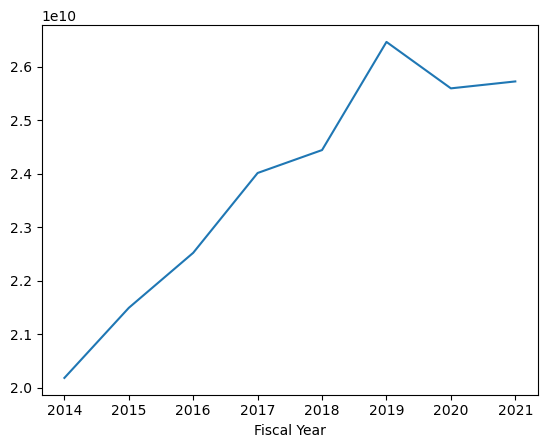

In [220]:
### ENTER CODE HERE ###
yearly_total_gross = nyc_full.groupby('Fiscal Year')['Regular Gross Paid'].sum()
yearly_total_gross = yearly_total_gross.sort_index()
print(yearly_total_gross)
yearly_total_gross.plot(kind='line')
year_peak= yearly_total_gross.idxmax()
peak_value= yearly_total_gross.max()
print(f"Highest total gross was {peak_value}")

**Q15:** How has the total number of employees for each fiscal year changed over time?  Again, be prepared to answer just some basic questions.

<Axes: xlabel='Fiscal Year', ylabel='Employees'>

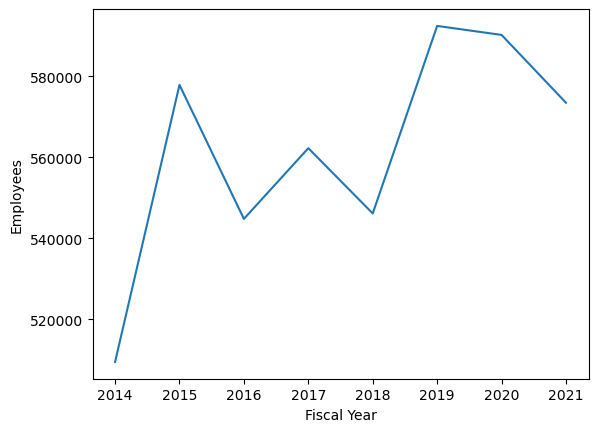

In [224]:
### ENTER CODE HERE ###
employee_counts = nyc_full.groupby('Fiscal Year').size()
employee_counts.plot(kind='line', ylabel='Employees')

**Q16:** For 2021, what percentage of individuals earned income per annum, per day and per hour?

In [226]:
### ENTER CODE HERE ###
pay_counts = nyc_2021['Pay Basis'].value_counts()
pay_percentages = (pay_counts / pay_counts.sum()) *100
print(pay_percentages)

Pay Basis
PER ANNUM          59.967183
PER DAY            24.034094
PER HOUR           15.675607
PRORATED ANNUAL     0.323117
Name: count, dtype: float64


**Q17:** Create a pivot table using the median of total gross pay with the index by agency name and columns broken down by pay basis category for 2021.  Include `margins=True`.  Be prepared to answer questions based on this pivot table.

In [228]:
### ENTER CODE HERE ###

pivot_table = pd.pivot_table(nyc_2021, values ='Regular Gross Paid', index='Agency Name', 
               columns='Pay Basis', aggfunc='mean', margins=True)
pivot_table.head()

Pay Basis,PER ANNUM,PER DAY,PER HOUR,PRORATED ANNUAL,All
Agency Name,,,,,
ADMIN FOR CHILDREN'S SVCS,61497.864379,85321.116111,34661.515882,NaN,61437.039663
ADMIN TRIALS AND HEARINGS,70183.215637,71870.933333,32385.001176,NaN,53341.464703
BOARD OF CORRECTION,73815.335517,NaN,NaN,NaN,73815.335517
BOARD OF ELECTION,51468.540819,NaN,19666.187695,NaN,43226.890539
BOARD OF ELECTION POLL WORKERS,NaN,NaN,1032.491615,NaN,1032.491615


**Q18:** What positions (grouped by titles) pay the most based on the median total gross pay in 2021?  Show the top 10.

In [230]:
### ENTER CODE HERE ###
title_medians = nyc_2021.groupby('Title Description')['Regular Gross Paid'].median()
top_10= title_medians.sort_values(ascending=False).head(10)
print(top_10)

Title Description
PENSION INVESTMENT ADVISOR             349014.960
CHAIR                                  328002.355
CHIEF ACTUARY                          311007.120
FIRST DEPUTY MAYOR                     290319.680
DIRECTOR OF  INVESTMENTS               264254.050
MAYOR                                  258021.790
CHANCELLOR                             254354.830
DEPUTY MAYOR                           251272.700
FIRST ASSISTANT CORPORATION COUNSEL    242587.270
COMMISSIONER OF LABOR RELATIONS        242486.660
Name: Regular Gross Paid, dtype: float64


**Q19:** What are the top 10 agencies that have the most total number of overtime hours for 2021?  

In [232]:
### ENTER CODE HERE ###
agency_ot= nyc_2021.groupby('Agency Name')['OT Hours'].sum()
top_10_OT= agency_ot.sort_values(ascending=False).head(10)
print(top_10_OT)

Agency Name
POLICE DEPARTMENT                 10815884.93
FIRE DEPARTMENT                    8220712.59
DEPARTMENT OF SANITATION           4206474.56
DEPARTMENT OF CORRECTION           3323294.05
NYC HOUSING AUTHORITY              2686245.50
HRA/DEPT OF SOCIAL SERVICES        1276660.51
DEPARTMENT OF TRANSPORTATION       1074099.24
DEPT OF HEALTH/MENTAL HYGIENE       867652.73
DEPT OF ENVIRONMENT PROTECTION      679410.40
ADMIN FOR CHILDREN'S SVCS           539092.21
Name: OT Hours, dtype: float64


**Q20:** Attempt to do this in one line of code by using `agg`.  For the 2021 data, groupby the agency name and get the mean for the base salary, the median for the total overtime paid, and the standard deviation for the total gross paid.  Save this as an object and be prepared to index it.

In [ ]:
### ENTER CODE HERE ###

<span style="color:maroon;">This material is for enrolled students' academic use only and protected under U.S. Copyright Laws. This content must not be shared outside the confines of this course, in line with Eastern University's academic integrity policies. Unauthorized reproduction, distribution, or transmission of this material, including but not limited to posting on third-party platforms like GitHub, is strictly prohibited and may lead to disciplinary action. You may not alter or remove any copyright or other notice from copies of any content taken from BrightSpace or Eastern University’s website.</span>

<span style="color:maroon;"> © Copyright Notice 2024, Eastern University - All Rights Reserved </span>